# EDAとデータの可視化

ここでは、以下のような工場の生産ラインを模擬したデータセット（トイデータ）を用いて、データを要約・可視化する**EDA**（exploratory data analysis：探索的データ分析）について学んでいきます。

![fig2_3.png](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig2_3.png)

書籍と同様、**データの要約**（2.3節）と**データの可視化**（2.4節）で節を分けて解説します。

データセットはch2_dataset_train.csv という名前で保存されており、Pandasでは以下のようにDataFrameに読み込むことができます。

In [1]:
# コード2.4: CSVファイルの読み込みとデータフレームの可視化
import pandas as pd

# CSVからpandas.DataFrameにデータ読み込み
df = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
# データフレームの可視化
df

,temp1,temp2,temp3,temp4,temp5,label
0,395.667201,353.492396,296.235526,152.251354,102.821694,normal
1,405.759147,357.049093,301.924367,149.051272,99.949597,normal
2,398.291243,344.117095,297.268122,150.198092,103.381724,normal
3,404.623143,353.359488,302.000303,147.123352,NaN,normal
4,NaN,352.573113,300.566646,153.667624,99.536412,normal
...,...,...,...,...,...,...
1015,410.563978,371.046845,310.685632,149.932727,104.033215,anomaly
1016,407.942575,361.861342,307.837379,152.001137,94.640144,anomaly
1017,414.170014,367.637874,314.735181,147.082402,96.444778,anomaly
1018,417.024310,372.612626,311.234704,150.355261,98.739640,anomaly


`temp1`〜`temp5`列が各温度計で計測された温度データを表しており、`label`列が正常データ（`normal`）か異常データ（`anomaly`）かを表しています。レコード数は、正常データが1000 個、異常データが20 個です。また、`NaN`は欠測値を表しています。以降はこのデータを用いて、分析や可視化を進めていきます。

まずは異常検知においてありがちな、異常データの取得が難しいケースを模擬して、正常データのみ用いるよう以下のようにデータをフィルタリングします

In [2]:
# コード2.5: 正常データのみを抽出
df_normal = df[df["label"] == "normal"]

## データの要約

ここでは書籍2.3節で解説したデータの要約。具体的には以下の情報をデータから得るための処理を実装していきます。

- 各変数の要約統計量（平均値、最大値、最小値、標準偏差、四分位数など）の算出
- 欠測値の確認：各変数における欠測データの数を確認し、補完や除去が必要か判断
- 変数間の相関：変数同士の相関係数を把握し、次元削減や変数選択の参考とする

### 各変数の要約統計量の算出

要約統計量はある変数を統計的に要約した値であり、代表的なものとして以下が挙げられます。

- 中心傾向を表す値：平均値（arithmetic mean）、中央値（median）、最頻値（mode）
- 散らばりを表す値：分散（variance）、標準偏差（standard deviation）、レンジ（range）、四分位偏差（quartile deviation）
- 形状を表す値：歪度（skewness）、尖度（kurtosis）
- 中心傾向以外の位置を表す値：最大値（maximum）、最小値（minimum）、四分位数（quartile points）
- その他：データの個数、ユニークなデータの個数

要約統計量を求められるのは数値型の変数のみなので、文字列などのカテゴリ変数を表す列は事前に削除します。以下の例では、データセット内の`label`列を削除したのち、各変数の平均値を求めています

In [3]:
# コード2.6: 平均値の計算
# "label"列を削除（数値型の列のみとする）
df_normal_val = df_normal.drop("label", axis=1)

# 平均値の計算
mean = df_normal_val.mean() # 全変数の平均値を計算
print(mean) # 計算した平均値を表示

temp1    400.215529
temp2    350.259795
temp3    300.035526
temp4    150.009343
temp5     99.899621
dtype: float64


求めた要約統計量を列に追加することで、複数の要約統計量を一つのpandas.DataFrameにまとめることもできます。

In [4]:
# コード2.7： 各種要約統計量の計算
# 結果格納用のDataFrame
df_summary_stats = pd.DataFrame(columns=df_normal_val.columns)
df_summary_stats.loc["mean"] = df_normal_val.mean() # 平均値
df_summary_stats.loc["median"] = df_normal_val.median() # 中央値
df_summary_stats.loc["mode"] = df_normal_val.mode().iloc[0] # 最頻値
df_summary_stats.loc["variance"] = df_normal_val.var(ddof=1) # 分散（不偏分散）
df_summary_stats.loc["stdev"] = df_normal_val.std(ddof=1) # 標準偏差（不偏標準偏差）
df_summary_stats.loc["skewness"] = df_normal_val.skew() # 歪度
df_summary_stats.loc["kurtosis"] = df_normal_val.kurtosis() # 尖度
df_summary_stats.loc["maximum"] = df_normal_val.max() # 最⼤値
df_summary_stats.loc["minimum"] = df_normal_val.min() # 最⼩値
df_summary_stats.loc["25%"] = df_normal_val.quantile(q=0.25) # 第一四分位点
df_summary_stats.loc["75%"] = df_normal_val.quantile(q=0.75) # 第三四分位点
# 計算した要約統計量を表示
df_summary_stats

,temp1,temp2,temp3,temp4,temp5
mean,400.215529,350.259795,300.035526,150.009343,99.899621
median,400.239736,350.104220,299.870226,150.069451,99.833606
mode,385.135866,337.162795,287.628938,141.133144,91.248520
variance,24.610997,26.108685,15.975084,8.422278,9.440936
stdev,4.960947,5.109666,3.996884,2.902116,3.072611
skewness,-0.128235,0.124851,0.130807,-0.008248,0.044555
kurtosis,-0.281706,-0.045647,-0.059755,0.115450,-0.130130
maximum,414.660220,368.931121,312.059560,159.813078,109.178594
minimum,385.135866,337.162795,287.628938,141.133144,91.248520
25%,396.880776,346.824188,297.437192,148.113718,97.820981


Pandasの各種メソッドで計算できる上記の統計量のうち、以下の特徴量には注意が必要です

- 最頻値（`mode`）は1変数あたり複数の値をとりうるので、Pandas.SeriesではなくPandas.DataFrameで出力される
- 分散（`variance`）と標準偏差（`stdev`）は`ddof=1`を指定すると不偏分散、`ddof=0`を指定すると（不偏でない）標本分散が計算される

また`describe`メソッドを用いることで、よく使用する要約統計量をまとめて求めることもできます。

In [5]:
# コード2.8： pandas.DataFrame.describeメソッドによる要約統計量の計算
# よく使用する要約統計量を一括計算
df_summary_describe = df_normal_val.describe()
# 計算した要約統計量を表示
df_summary_describe

,temp1,temp2,temp3,temp4,temp5
count,912.000000,1000.000000,1000.000000,1000.000000,936.000000
mean,400.215529,350.259795,300.035526,150.009343,99.899621
std,4.960947,5.109666,3.996884,2.902116,3.072611
min,385.135866,337.162795,287.628938,141.133144,91.248520
25%,396.880776,346.824188,297.437192,148.113718,97.820981
50%,400.239736,350.104220,299.870226,150.069451,99.833606
75%,403.792623,353.546393,302.708459,151.735857,101.932281
max,414.660220,368.931121,312.059560,159.813078,109.178594


### 各変数の欠測値の数の算出

本来記録されるべき値が何らかの理由で欠けてしまった**欠測値**（missing values）がデータに含まれていると、多くの異常検知アルゴリズムは動作しません。よって事前に補完（imputation）や除外などの操作を実施する必要があります。
このための前段階として、各変数にどの程度の欠測値が含まれるかを把握する必要があります。

Pandasにおいては、DataFrameの`isnull`メソッドで欠測の有無を判定したのち、`sum`メソッドで欠測値の数を求めることができます。

In [6]:
# コード2.9： 各変数の欠測値の数の算出
df_missing = pd.DataFrame(columns=df_normal.columns) # 結果格納用のDataFrame
df_missing.loc["not_missing"] = df_normal.count() # 欠測していないデータの個数
df_missing.loc["missing"] = df_normal.isnull().sum() # 欠測値の個数
# データの総数（欠測値＋欠測していないデータ）
df_missing.loc["total"] = len(df_normal)
# 欠測率
df_missing.loc["missing_ratio"] = df_missing.loc["missing"] / df_missing.loc["total"]
# 計算した要約統計量を表示
df_missing

,temp1,temp2,temp3,temp4,temp5,label
not_missing,912.000,1000.0,1000.0,1000.0,936.000,1000.0
missing,88.000,0.0,0.0,0.0,64.000,0.0
total,1000.000,1000.0,1000.0,1000.0,1000.000,1000.0
missing_ratio,0.088,0.0,0.0,0.0,0.064,0.0


変数`temp1`、`temp5`に欠測値が含まれていることがわかります。

### 変数同士の相関係数と共分散の算出

ある変数が変化した際に他の変数も同じ方向に変化する関係、すなわち**相関**（correlation）の存在は、モデルの性能や解釈に⼤きな影響を与えます。
例えば7章で紹介する線形回帰では、変数間の相関が大きいと**多重共線性**と呼ばれる問題が発生し、学習の不安定化や性能の低下を招きます。
このような相関に関する情報を開発の初期段階で把握することで、

- 多重共線性に強いアルゴリズムを選択する
- 高い相関を持つ変数を事前に除外する

といった判断が可能になり、モデル開発をより効果的に進められます。

変数同士の相関を数値で表すには、**共分散**（covariance）と**相関係数**（correlation coefficient）が広く用いられています。
共分散は変数のスケールの影響を強く受け、分散が大きい変数の相関が過大評価されてしまいます。よって相関そのものを見る用途では、共分散をスケーリングして変数ごとのスケールを揃えた、相関係数の方が適しています。

`pandas.DataFrame`では`cov`メソッドを用いることで、全変数の共分散と分散を行列形式で一括計算した**分散共分散行列**（covariance matrix）を求められます

In [7]:
# コード2.10： 分散共分散行列の計算
cov_mat = df_normal_val.cov(ddof=0)
# 計算した分散共分散行列を表示
cov_mat

,temp1,temp2,temp3,temp4,temp5
temp1,24.610997,14.544698,9.608153,0.645634,-0.657667
temp2,14.544698,26.108685,12.800128,0.735185,-0.530256
temp3,9.608153,12.800128,15.975084,0.536521,0.006123
temp4,0.645634,0.735185,0.536521,8.422278,-0.009119
temp5,-0.657667,-0.530256,0.006123,-0.009119,9.440936


相関係数に関しては、`pandas.DataFrame`の`corr`メソッドを用いることで、全変数の相関係数を行列形式で一括計算した**相関係数行列**（correlation matrix）を求められます

In [8]:
# コード2.11： 相関係数行列の計算
# 相関係数行列を算出
corr_mat = df_normal_val.corr(method="pearson")
# 計算した相関係数行列を表示
corr_mat

,temp1,temp2,temp3,temp4,temp5
temp1,1.000000,0.574214,0.479974,0.044886,-0.043389
temp2,0.574214,1.000000,0.626759,0.049578,-0.033635
temp3,0.479974,0.626759,1.000000,0.046254,0.000495
temp4,0.044886,0.049578,0.046254,1.000000,-0.001025
temp5,-0.043389,-0.033635,0.000495,-0.001025,1.000000


変数`temp1`、`temp2`、`temp3`は0.4以上の比較的強い相関を持っており、これらの変数は互いに依存し合っている、すなわち重複した情報を持っている可能性が高いと言えるでしょ
う。とはいえ片方の変数を消去できるほど高い相関ではない（9章で紹介するVIFが5を超えるほどではない）ので、ひとまずすべての変数を使用する方向性でモデルを検討してよさそうです。一方で`temp4`、`temp5`は他の変数との相関が⼩さく、独立性の高い変数と言え、これらの変数もモデルの検討に含めることが適切でしょう。

## データの可視化

ここまで求めたデータの要約統計量は、データの特徴を定量的に把握できるという利点を持ちます。一方で要約特徴量は、あくまで膨⼤なデータの特徴を単純化した数値にすぎず、要約によって多くの情報が失われています。これを補って多角的な分析を実現するためには、**グラフを用いて視覚的にデータを可視化**（プロット）することが有効です。ここでは可視化するデータの次元ごとに、代表的な可視化方法と異常検知において見るべき観点を解説します。

### 1次元データの可視化

データの特徴をグラフで可視化する最も基本的な方法は、一つの変数を対象とした1次元データの可視化です。変数が複数ある場合も、第一段階としてこの方法で変数ごとにデータを可視化し、特徴を把握することが推奨されます。具体的には、以下のような情報を可視化を通じて得ます。

- データの分布形状（4章で紹介する確率密度関数・確率質量関数に対応）
- 正常データと異常データの分離性（異常データが利用可能な場合）

ここではヒストグラム、KDEを用いてこれらの情報を得る方法を実践します。

#### ヒストグラム

**ヒストグラム**（histogram）とは、変数の値をビン（bin）と呼ばれる区間に分割して横軸にとり、その区間に含まれるデータの数（度数）を縦軸にとったグラフです。ヒストグラムを通じてデータの分布形状を視覚的に把握できます。
ここではMatplotlibやSeabornライブラリを用いてヒストグラムを描画する、以下3種類の方法を紹介します。

- Matplotlibのpyplot API（The implicit API）
- MatplotlibのAxes（The explicit API）
- Seaborn

##### Matplotlibのpyplot API

Matplotlibで手軽にグラフを描画するには、pyplot API（The implicit API）を使用すると便利です。pyplot APIでは、`import matplotlib.pyplot as plt`でpyplotモジュールをimportしたのち、`plt.グラフを描画する関数名`と実行することで、簡単にグラフを描画できます。

ヒストグラムを描画するには、`plt.hist`関数を用います。以下の例では、データセット中の`temp1`変数の分布をヒストグラムで可視化しています。

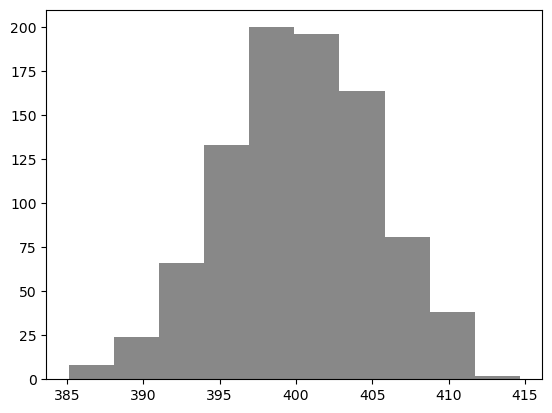

In [9]:
# コード2.12： Matplotlibのpyplot APIによるヒストグラムの描画
import matplotlib.pyplot as plt

# 変数"temp1"のヒストグラムを表示（カラーコードで色指定）
plt.hist(x=df_normal_val["temp1"], color="#888888")
# 図を表示
plt.show()

ヒストグラムの形状はビン数により⼤きく変わるため、適切な分布形状の把握にはビン数の選択が重要です。
ビン数を手動で指定することもできますが、適切なビン数を⾃動で計算する方法として、以下の**スタージェスの公式**（Sturges’ rule）がよく利用されます。

<img src="https://latex.codecogs.com/svg.image?
n_h = \log 2(N) + 1
" />

$N$はサンプルサイズを表します。

例として、今回使用しているデータセットの場合、サンプルサイズ$N = 1000$を代入して、$n_h\simeq 11$と求められます。Matplotlibでは、`plt.hist`関数の`bins`引数に`"sturges"`と指定
することで、⾃動でスタージェスの公式に基づくビン数が適用されます。以下に、スタージェスの公式を適用した場合と、ビン数=30を指定してより細かくビンを分割した場合との比較プロット例を示します。

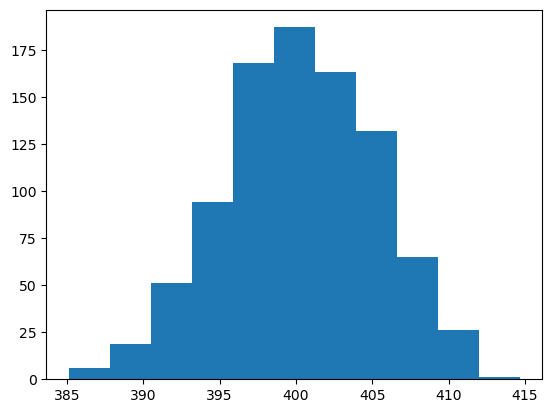

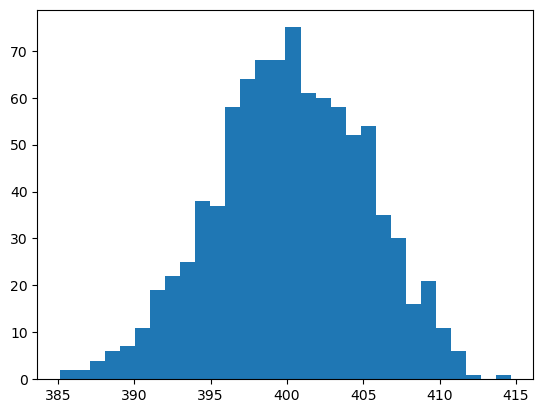

In [10]:
# コード2.13： スタージェスの公式の適用
# スタージェスの公式に基づきビン数を指定（ビン数=11）
plt.hist(x=df_normal_val["temp1"], bins="sturges")
# 1枚目の図を表示
plt.show()

# ビン数を30に指定
plt.hist(x=df_normal_val["temp1"], bins=30)
# 2枚目の図を表示
plt.show()

スタージェスの公式以外にもさまざまなビン数の⾃動計算方法がありますが、実装方法も含めた詳細は[Numpyの公式ドキュメント](https://numpy.org/doc/stable/reference/generated/numpy.histogram_bin_edges.html#numpy.histogram_bin_edges)を参照してください。

##### Matplotlib のAxes を使用

pyplot APIは手軽にグラフを描画するには便利な方法ですが、複数のグラフを組み合わせた複雑な描画は苦手としています。このような⾃由度の高い描画を実現したい場合、Axes（[The explicit API](https://matplotlib.org/stable/api/index.html#the-explicit-api)）による描画が便利です。

The explicit APIでは、図全体のキャンバスに相当する[`Figure`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure)と、個々の図に相当する[`Axes`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html#matplotlib.axes.Axes)との階層構造を用いてグラフを表現します。

実装時は`Figure`と`Axes`を別々に生成できますが、[plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)関数を利用すると、両者をまとめて生成できるため便利です。以下に示す実装例では、データセット中の5つの変数全てのヒストグラムを一括表示しています。

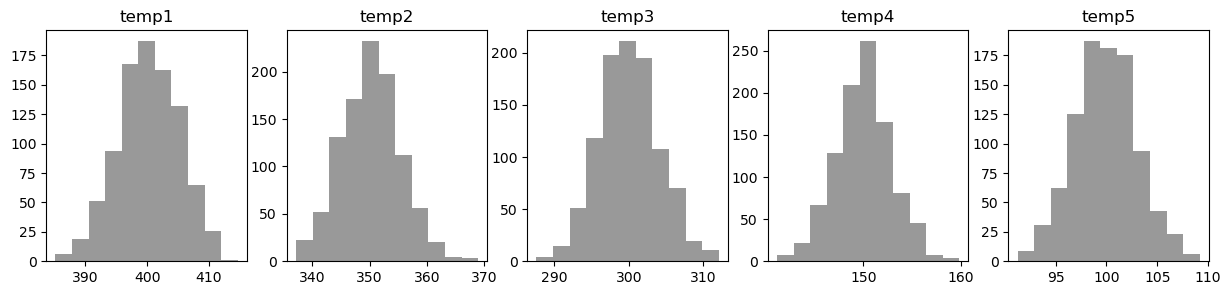

In [11]:
# コード2.14： MatplotlibのAxesによるヒストグラムの描画
# 描画用のFigureとAxesを生成（Axesは5個生成。figsizeでFigureのサイズを指定）
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(15, 3))

# すべての変数をループで走査（enumerateで何番目の変数かも取得）
for i, colname in enumerate(df_normal_val.columns):
    # Axes.hist()メソッドでヒストグラム描画（スタージェスの公式適用）
    axes[i].hist(x=df_normal_val[colname], bins="sturges",
                  color="#999999")
    # 変数名を図のタイトルとして追加
    axes[i].set_title(colname)

# 図を表示
plt.show()

##### Seabornを使用

SeabornはMatplotlibをベースとした高機能な可視化ライブラリであり、より美しく複雑なグラフを簡単に描画できます。Seabornでは、`import seaborn as sns`でライブラリをimportしたのち、[`sns.histplot`](https://seaborn.pydata.org/generated/seaborn.histplot.html)関数でヒストグラムを描画できます。以下に示す実装例では、サンプルデータ中の全変数のヒストグラムを、正常データと異常データで色分けして表示しています。

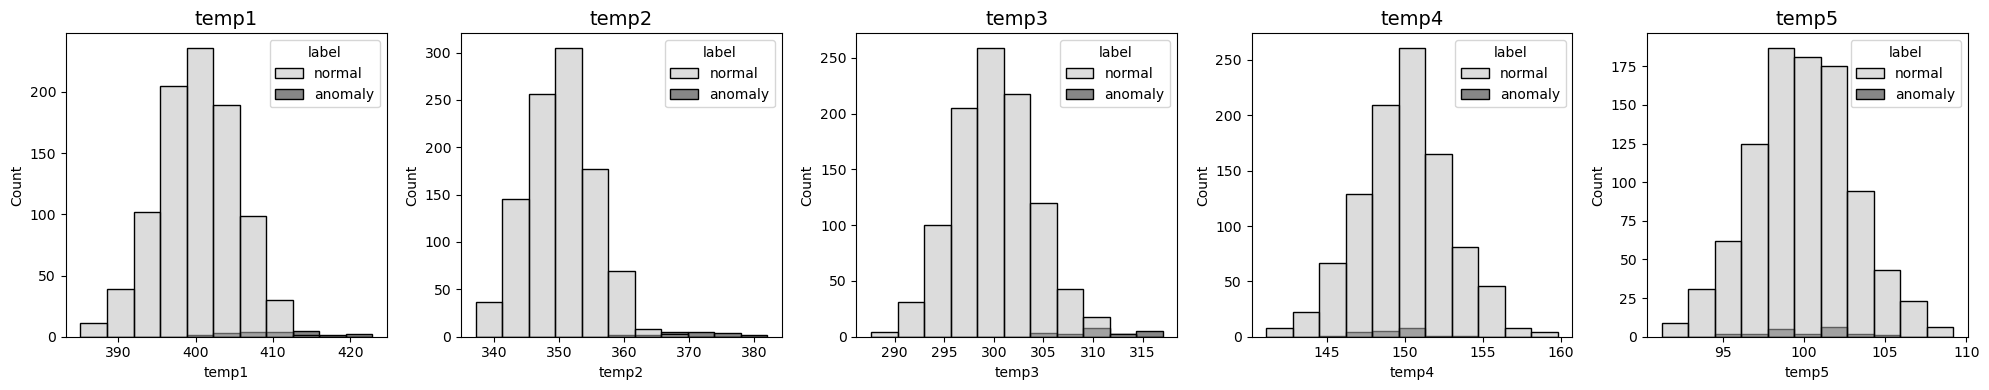

In [12]:
# コード2.15 Seabornによるヒストグラムの描画

import seaborn as sns

# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))

# すべての変数をループで走査
for i, colname in enumerate(df_normal_val.columns):
    # sns.histplot()関数でヒストグラム描画
    sns.histplot(
        data=df, # DataFrame
        x=colname, # ヒストグラム描画対象の列名
        hue="label", # 色分け対象の列名
        multiple="layer", # 色分けデータを積み上げるか重ねるか
        bins="sturges", # ビン数（今回はスタージェスの公式）
        palette=["#bbbbbb", "#111111"], # 色分けのカラーパレット
        ax=axes[i] # 描画対象のAxes
    )
    # 変数名を図のタイトルとして追加
    axes[i].set_title(colname, fontsize=14)

# 字が重なるのでtight_layoutにする
plt.tight_layout()
# 図を表示
plt.show()

上のコードでは、Matplotlibで作成した`Axes`のインスタンス（実装例中の`axes[i]`）を、`sns.histplot`関数の`ax`引数に渡すことで、Matplotlibのキャンバス内にヒストグラムを描
画しています。このように、Matplotlibの機能とSeabornの機能を組み合わせて活用することで、⾃由度の高い描画が可能となります。

また、この例では正常データの数と比べて異常データの数が極端に少ない不均衡データのため、縦軸を度数（`count`）で表示すると、異常データのヒストグラムが縦方向に潰れて見づらくなっています。これに対応するには、以下に示す実装例のように正常データと異常データのヒストグラムを別々にプロットした上で、`stat`引数に`"density"`を指定して縦軸を確率密度にするとよいでしょう。

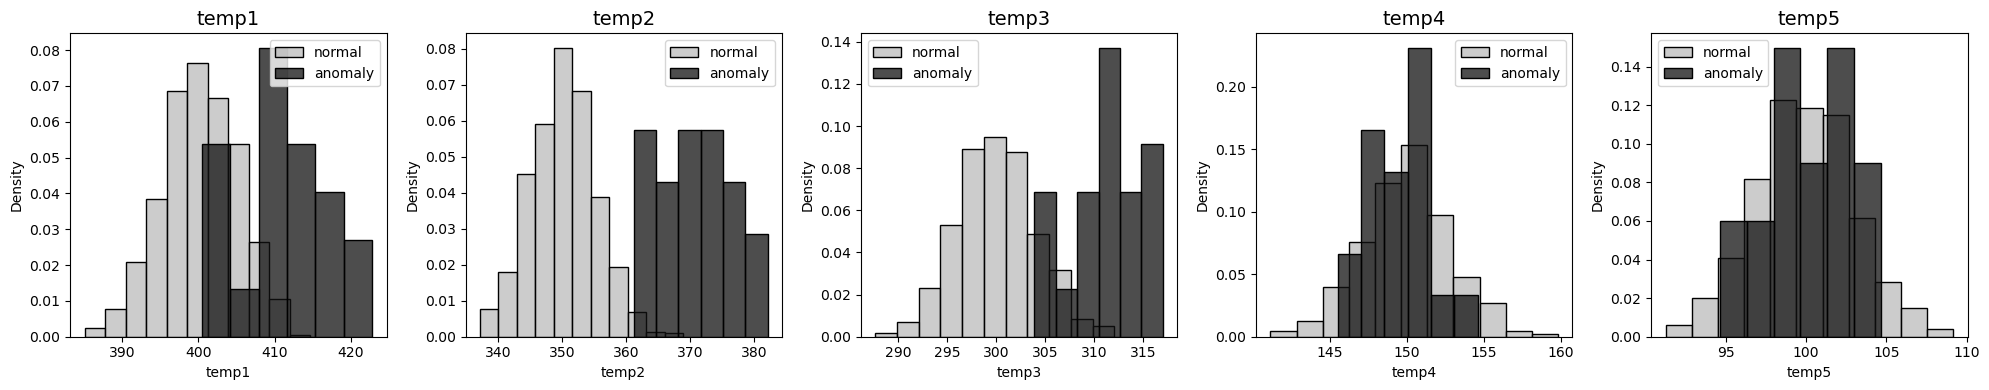

In [13]:
# コード2.16 縦軸を確率密度にしてヒストグラムを描画
# 異常データのみ抽出
df_anomaly_val = df[df["label"] == "anomaly"].drop("label", axis=1)
# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))

# すべての変数をループで走査
for i, colname in enumerate(df_normal_val.columns):
    # 正常データのヒストグラム描画
    sns.histplot(data=df_normal_val[colname], bins="sturges",
                 color="#bbbbbb", ax=axes[i],
                 stat="density", label="normal")
    # 異常データのヒストグラム描画
    sns.histplot(data=df_anomaly_val[colname], bins="sturges",
                 color="#111111", ax=axes[i],
                 stat="density", label="anomaly")
    # 凡例を追加
    axes[i].legend()
    # 変数名を図のタイトルとして追加
    axes[i].set_title(colname, fontsize=14)

plt.tight_layout()
plt.show()

描画結果を見ると、変数`temp2`において正常データと異常データの分離性が最も高く、`temp3`および`temp1`が続くことがわかります。後述のサンプルデータ作成時における正常データに対する異常データの平均値変化量もこの順番を示すことから、ヒストグラムで変数ごとの正常データと異常データの判別性に目星が付けられることがわかります。

#### KDE（カーネル密度推定）

ヒストグラムのような離散的な分布の可視化手法は、データの⼤まかな分布形状を理解するには有効です。一方でヒストグラムは、ビンの数や区切り方によって形状が⼤きく変わることから、特に連続型変数において確率分布の真の姿を歪めてしまう可能性があります。このような課題の解決に役立つのが、**KDE**（kernel density estimation：カーネル密度推定）による可視化です。KDEを用いることで、データから連続的な確率分布を推定でき、ヒストグラムよりもなめらかな形で分布形状を把握できます。

KDEでは、データ$\boldsymbol{X}=(\boldsymbol{x}^{(1)}, \boldsymbol{x}^{(2)}, \cdots, \boldsymbol{x}^{(N)})$が与えられたとき、特徴空間上のある点$\boldsymbol{x}$における確率密度関数$p(\boldsymbol{x})$ を、以下のように推定します。

<img src="https://latex.codecogs.com/svg.image?
p(\boldsymbol{x})=\frac{1}{N}\sum_{i=1}^N K_\text{H}(\boldsymbol{x},\boldsymbol{x}^{(i)})
" />

ここで$K_\text{H}(\boldsymbol{x},\boldsymbol{x}^{(i)})$はカーネル関数と呼ばれ、データ1 個ごとに確率密度関数を割り当てる
役割を果たします。
代表的なカーネル関数として、多変数においては分散$h^2$、平均ベクトル$\boldsymbol{x}^{(i)}$の正規分布（ガウスカーネル）

<img src="https://latex.codecogs.com/svg.image?
K_h(\boldsymbol{x},\boldsymbol{x}^{(i)})=\Bigl(\frac{1}{2\pi h^2}\Bigr)^{\frac{M}{2}} \exp\Bigl(-\frac{1}{2h^2}\|\boldsymbol{x}-\boldsymbol{x}^{(i)}\|^2\Bigr)
" />

がよく用いられます。

Seabornの[`sns.kdeplot`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)関数を使用すると、KDEを簡単にプロットすることができます。以下に示す実装例では、データセット中の正常データと異常データの各変数に対して、KDEで推定した確率密度関数を一括表示しています。


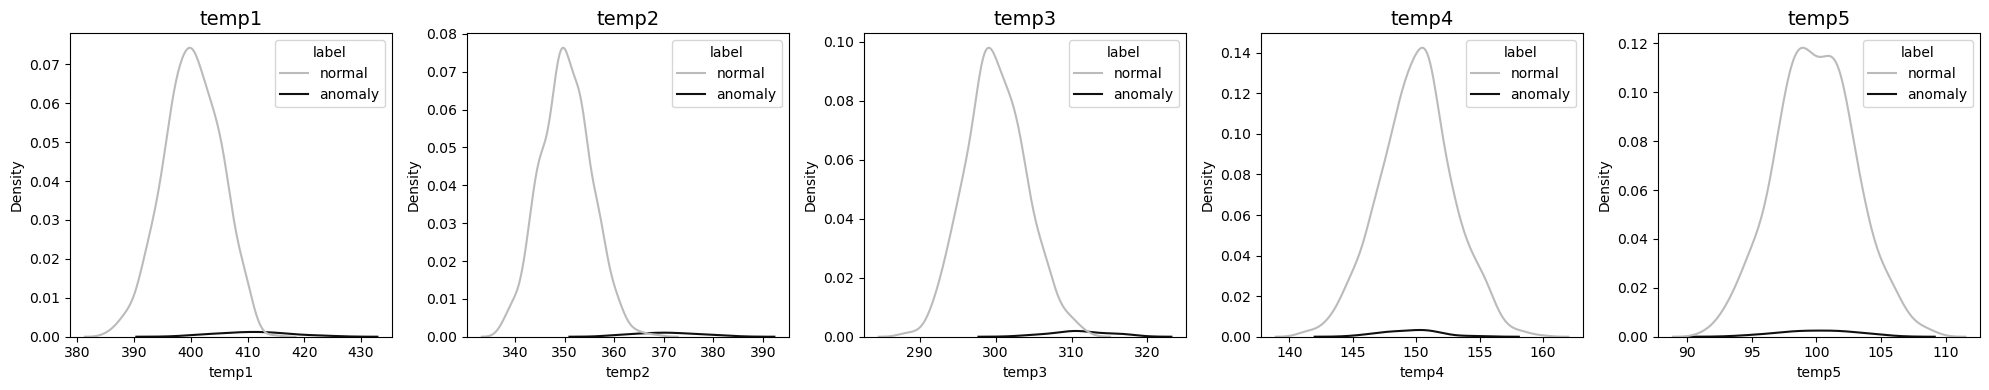

In [14]:
# コード2.17 KDE の描画
# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))
# すべての変数をループで走査
for i, colname in enumerate(df_normal_val.columns):
    # sns.kdeplot()関数でKDE描画
    sns.kdeplot(
        data=df, # DataFrame
        x=colname, # KDE描画対象の列名
        hue="label", # 色分け対象の列名
        multiple="layer", # 色分けデータを積み上げるか重ねるか
        palette=["#bbbbbb", "#111111"], # 色分けのカラーパレット
        ax=axes[i] # 描画対象のAxes
    )
    axes[i].set_title(colname, fontsize=14)

plt.tight_layout()
plt.show()

`sns.kdeplot`関数によるKDEの推定は正常、異常を分けずに行われます。よって今回のように異常データの数が少ない不均衡データでは、異常データの確率密度関数が⼩さくなって見づらくなります。そこで以下のように実装を変え、異常データと正常データのKDEを別々に推定します。

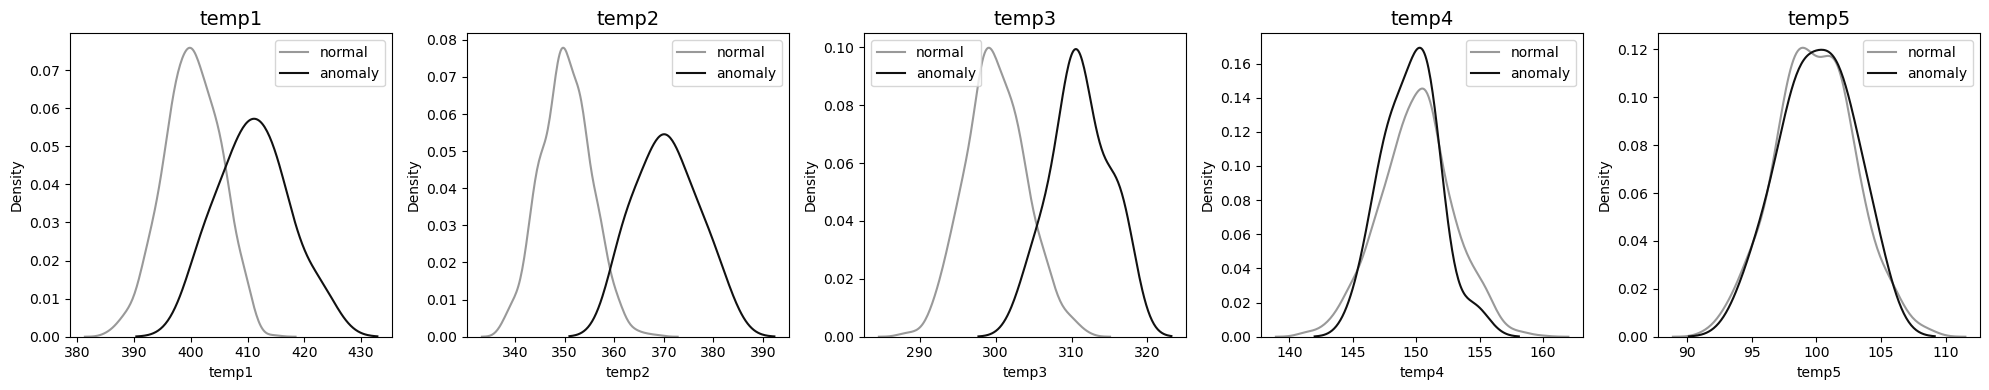

In [15]:
# コード2.18 正常データと異常データから別々に推定したKDEの描画
# 異常データのみ抽出
df_anomaly_val = df[df["label"] == "anomaly"].drop("label", axis=1)
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))

for i, colname in enumerate(df_normal_val.columns):
    # sns.kdeplot()関数でKDE描画
    # 正常データ
    sns.kdeplot(data=df_normal_val, x=colname, color="#999999",
                ax=axes[i], label="normal")
    # 異常データ
    sns.kdeplot(data=df_anomaly_val, x=colname, color="#111111",
                ax=axes[i], label="anomaly")
    # 色分けの凡例作成
    axes[i].legend()
    axes[i].set_title(colname, fontsize=14)

plt.tight_layout()
plt.show()

正常データと異常データのKDEを別々に実施することで、両者の確率密度関数のスケールが揃って見やすくなりました。

#### 正常データの可視化において見るべき観点

ここまでのヒストグラムやKDEを用いた1次元データの可視化では、正常データと異常データの分離性に着目してきました。一方で、実用においては異常データの収集が困難なケースも多く、そのようなケースでは正常データとの分離性を判断することができません。この場合、正常データの分布形状のみを可視化・分析することとなります。
このような正常データの分析では、特に以下の観点が重要となります。

1. 分布形状が正規分布に近いか（左右対称で釣鐘型か）
2. 分布形状が正規分布でない場合、適合しそうな他の確率分布は何か
3. 外れ値が存在するか
4. 外れ値が存在する場合、ドメイン知識に基づく調査が可能か

### 2次元データの可視化

ここまでは、単一の変数を対象とした1次元の可視化手法を紹介しました。一方で、変数同士の相関関係を可視化・分析するためには、二つの変数を同時に可視化できる、2次元の手法が有効です。ここではその代表例として、散布図と2次元KDEについて紹介します。

#### 散布図

散布図とは、1個目の変数を横軸、2個目の変数を縦軸にとり、データ各点をその位置にプロットするグラフです。異常検知においては2変数間の相関関係や、正常・異常データの判別性の確認に有効です。
散布図をプロットするには、Seabornの`sns.scatterplot`関数を使用すると便利です。

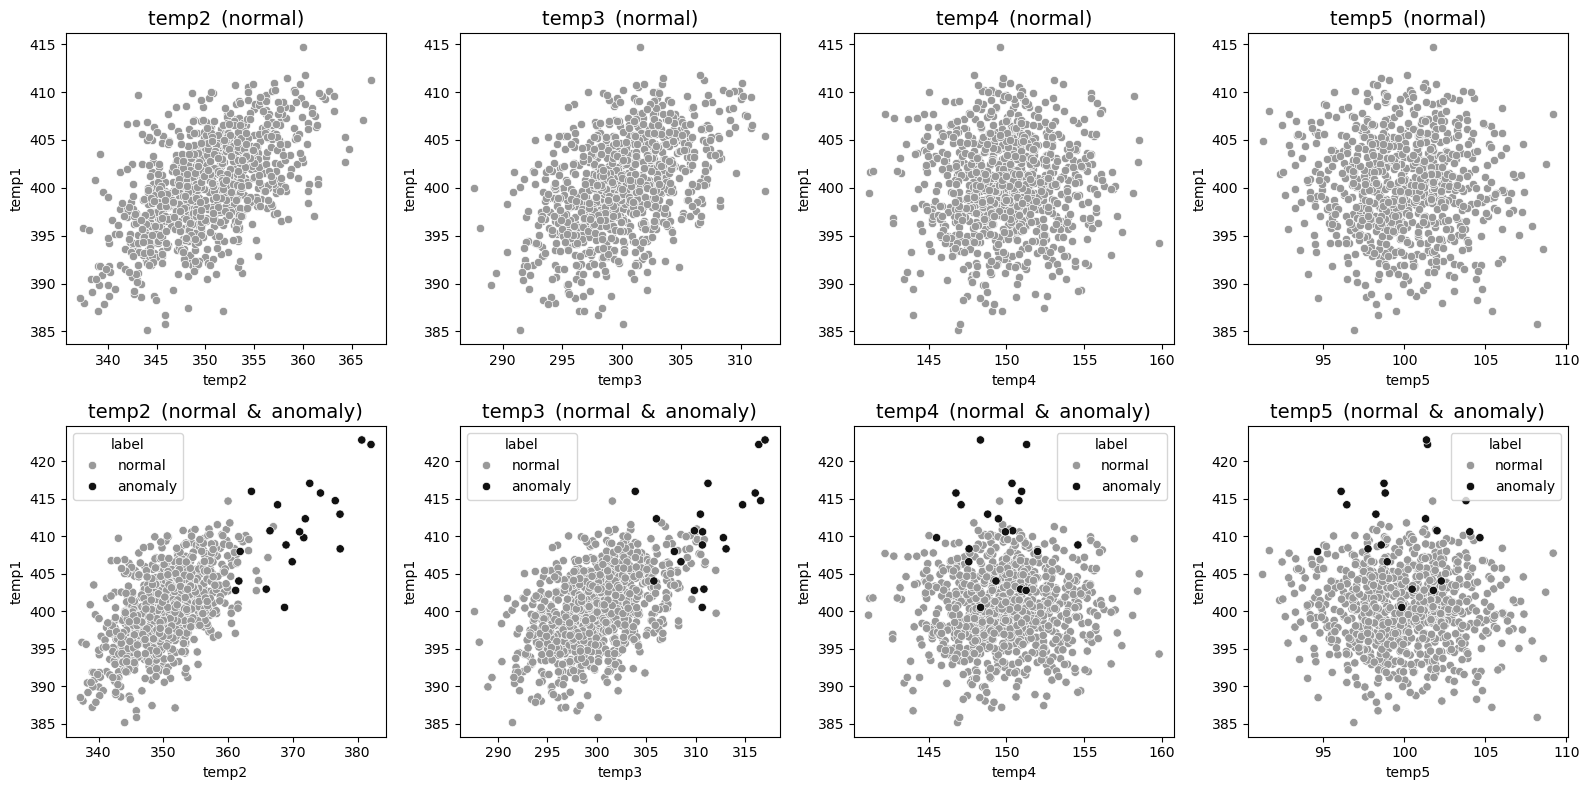

In [16]:
# コード2.19 散布図の描画
# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))

# "temp1"以外の変数をループで走査
colnames = [c for c in df_normal_val.columns if c != "temp1"]
for i, colname in enumerate(colnames):
    # 正常データのみの散布図描画
    sns.scatterplot(
        data=df_normal_val, # DataFrame
        x=colname, # 散布図の横軸とする変数名
        y="temp1", # 散布図の縦軸とする変数名
        color="#999999", # 点の色
        ax=axes[0][i] # 描画対象のAxes
    )
    axes[0][i].set_title(f"{colname} (normal)", fontsize=14)
    # 正常データと異常データの散布図描画
    sns.scatterplot(
        data=df, # DataFrame
        x=colname, # 散布図の横軸とする変数名
        y="temp1", # 散布図の縦軸とする変数名
        hue="label", # 色分け対象の列名
        palette=["#999999", "#111111"], # 色分けのカラーパレット
        ax=axes[1][i] # 描画対象のAxes
    )
    axes[1][i].set_title(f"{colname} (normal & anomaly)", fontsize=14)

plt.tight_layout()
plt.show()

上段の正常データのみを描画した散布図は、異常データが取得できないケースで得られるグラフを想定しています。このグラフに対しては、以下の観点で分析を行うとよいでしょう。

- 外れ値の有無：1次元のヒストグラムでは見落としやすい外れ値も、2軸を用いた散布図で
は情報量が増えるため発見しやすくなる
- 2変数の相関関係：「直線的か非線形か」、「全体の傾向と外れ値のどちらが影響しているか」など、相関係数では把握できない、相関の質的な特徴を分析する

この例では、`temp1`と`temp2`、および`temp1`と`temp3`変数に関して、全体傾向として直線的な正の相関があることがわかります。

下段の散布図は、正常データと異常データを異なる色で描画しており、異常データが取得できるケースで得られるグラフを想定しています。正常データで分析していた観点に加えて、正常データと異常データの分離性を評価するとよいでしょう。散布図で把握した分離性に応じて、この後作成する異常検知アルゴリズムに期待できる⼤まかな性能を以下に示します。

1. 正常と異常が完全に分離している→高性能な異常検知が期待できる
2. 正常と異常が一部重なるが、分布に明確な違いがある→ある程度の検知性能は見込めるが、誤報や見逃しのリスクがある
3. 正常と異常の分布がほぼ同じ→この2 変数の組み合わせのみでは、異常検知は困難と判断される

今回の可視化では、どの変数ペアにおいても分布に差が見られるが、完全には分離されていないため、上記の2のケースに相当します。

#### 2次元KDE

散布図は、2変数間の関係性を視覚的に把握するのに有効な手法ですが、データ点が密集している場合や重なりが多い場合には、データの分布傾向をとらえることが難しくなります。このようなケースでは、KDEを用いた連続的な分布の可視化が有効です。

2次元のKDEを実装するには、1次元と同様Seabornの`sns.kdeplot`関数を用います。以下に示す実装例では、先ほどの散布図と同様の変数およびデータをKDEで可視化しています。

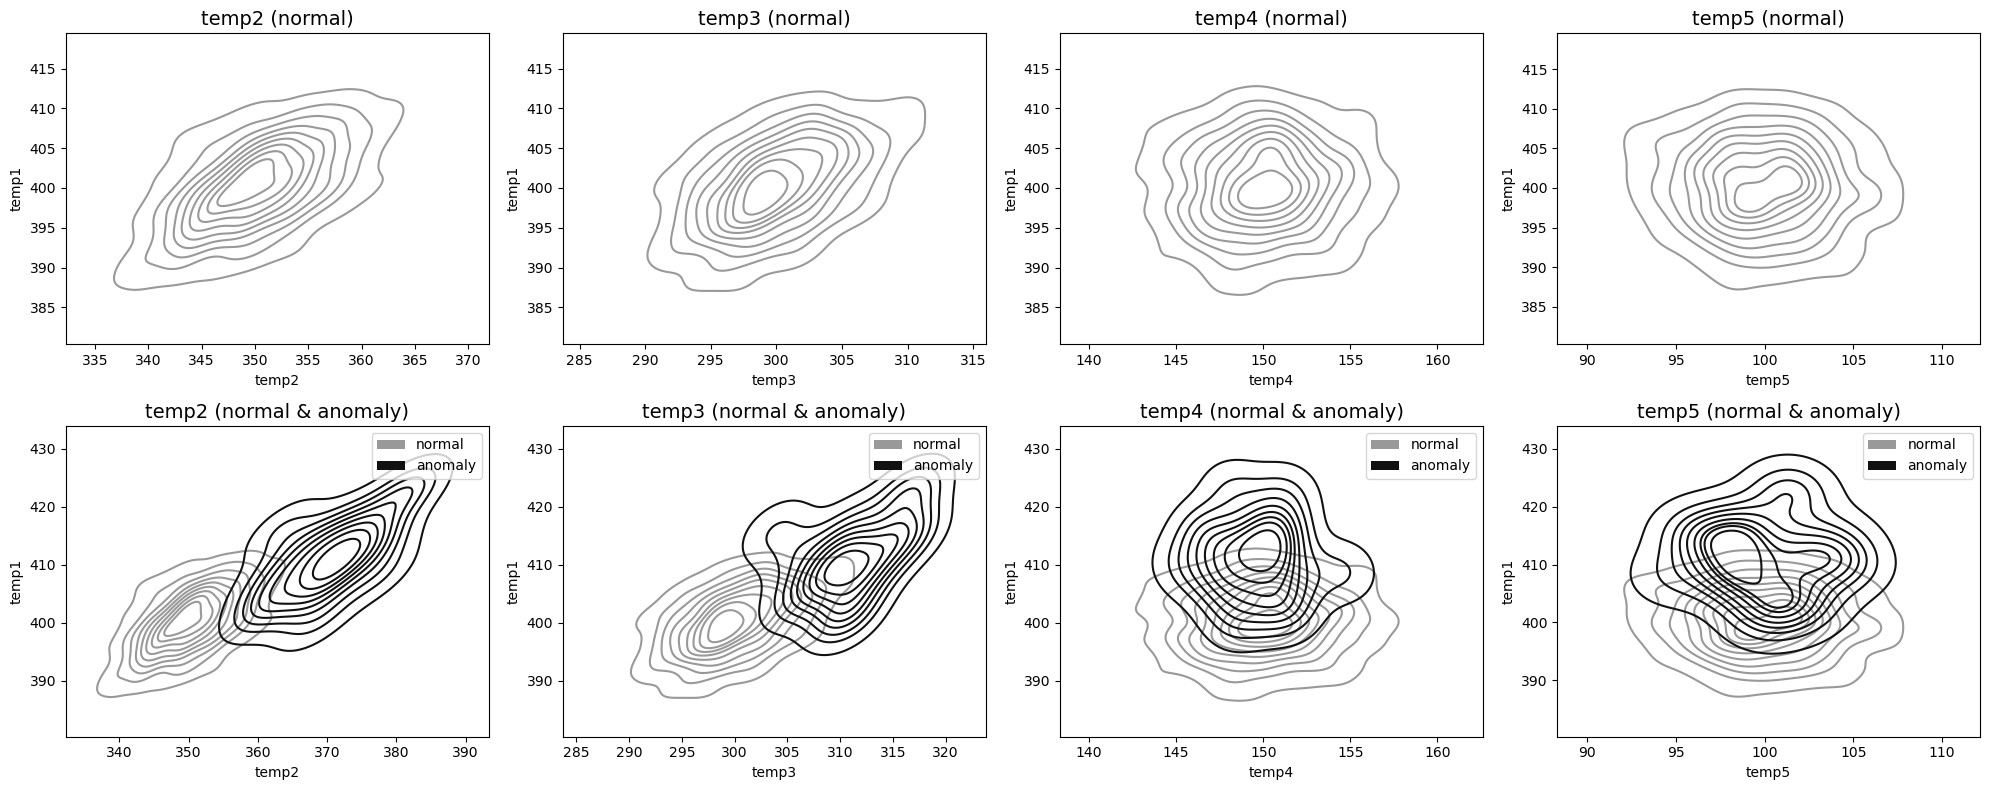

In [17]:
# コード2.20 2次元KDEの描画
import matplotlib.patches as mpatches

# 異常データのみ抽出
df_anomaly_val = df[df["label"] == "anomaly"].drop("label", axis=1)
# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 8))

# "temp1"以外の変数をループで走査
colnames = [c for c in df_normal_val.columns if c != "temp1"]
for i, colname in enumerate(colnames):
    # 正常データのみの散布図描画
    sns.kdeplot(
        data=df_normal_val,  # DataFrame
        x=colname,  # 散布図の横軸とする変数名
        y="temp1",  # 散布図の縦軸とする変数名
        color="#999999",  # 線の色
        ax=axes[0][i]  # 描画対象のAxes
    )
    axes[0][i].set_title(f"{colname} (normal)", fontsize=14)
    # 正常データのKDE
    sns.kdeplot(data=df_normal_val, x=colname, y="temp1",
                color="#999999", ax=axes[1][i], label="normal")
    # 異常データのKDE
    sns.kdeplot(data=df_anomaly_val, x=colname, y="temp1",
                color="#111111", ax=axes[1][i], label="anomaly")
    # 色分けの凡例作成
    handles = [mpatches.Patch(facecolor="#999999", label="normal"),
            mpatches.Patch(facecolor="#111111", label="anomaly")]
    axes[1][i].legend(handles=handles)
    axes[1][i].set_title(f"{colname} (normal & anomaly)", fontsize=14)

plt.tight_layout()
plt.show()

KDEで求めた確率密度関数が等高線で表示されていることがわかります。なお1次元のときと同様、正常データと異常データを同時にプロットして`hue`引数で色分けすると、異常データの数が少なすぎて等高線が表示されないので、実装例のように両者を分けてプロットするとよいでしょう。

### 多次元データの可視化

3次元以上のデータの可視化には困難がともないます。例えば3次元データは3D散布図で可視化できますが、視点によってはデータ同士が重なって死角が多く発生します。さらに4次元以上のデータに関しては、そもそも視覚的にプロットすることはできません。

このような理由から、多次元データの可視化では、直接的に座標空間へプロットする方法ではなく、間接的にデータの構造や傾向を可視化する手法が用いられます。その代表例として、pairplotと次元削減について紹介します。

#### pairplot

Seabornに用意されている`seaborn.pairplot`関数を用いると、すべての変数の組み合わせに対してマトリクス形式で散布図やKDEを⾃動生成します。これにより多数の変数間の相関関係や、正常と異常の分離性を一括で可視化できます。

以下に示す実装例では、サンプルデータに対してpairplot による散布図描画を実行しています。

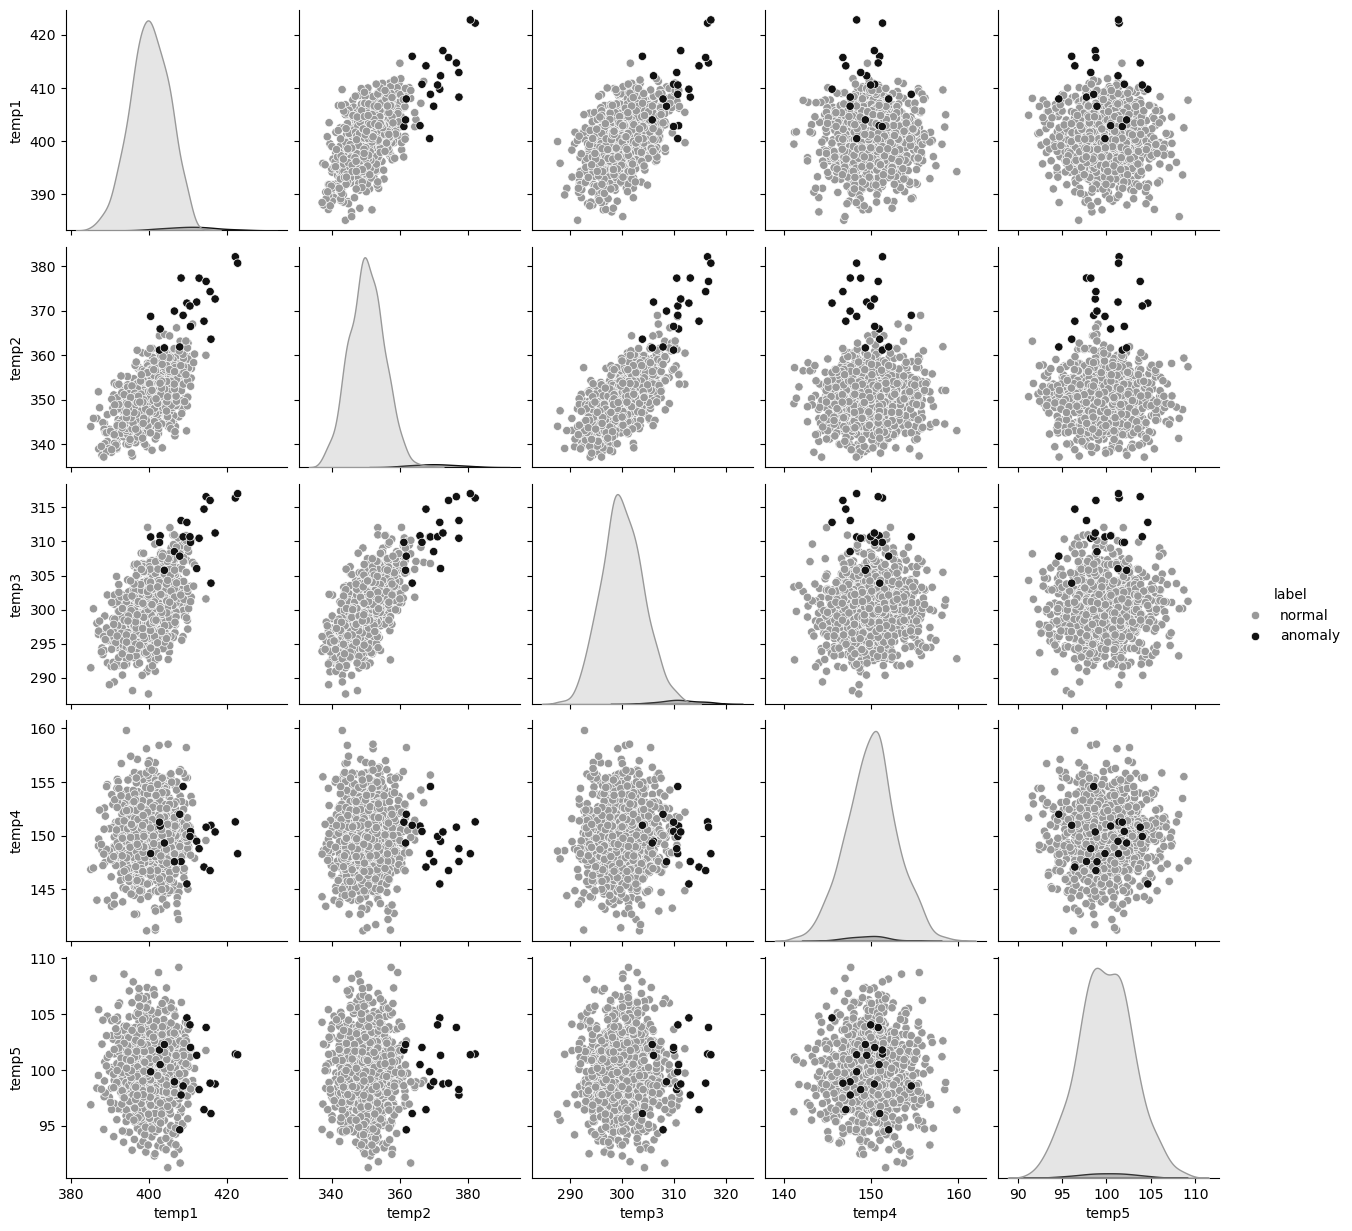

In [18]:
# コード2.21 pairplotの描画
sns.pairplot(
    data=df,  # DataFrame
    hue="label", # 色分け対象の列名
    palette=["#999999", "#111111"]  # 色分けのカラーパレット
)
plt.show()

pairplotの出力では、左下と右上の散布図は同じ内容であるため、通常はいずれかの散布図のみを確認すれば十分です。また、対角成分にはそれぞれの変数の1次元KDEが表示され、変数ごとの分布も同時に確認できます。

#### 次元削減（主成分分析）による可視化

次元削減とは、高次元のデータの特徴をなるべく保持しながら、低次元のデータに変換する手法全般を指します。可視化用途においては、次元削減で2次元に削減したデータを散布図としてプロットすることで、高次元データのクラスタ構造や傾向を人間が理解可能な形で把握できます。
ここでは代表的な手法として、**主成分分析**（principal component analysis：PCA）を可視化に活用する方法を紹介します（主成分分析の原理については9章で改めて解説します）。

主成分分析の実装には、scikit-learnの`sklearn.decomposition.PCA`クラスを使用します。主成分分析は欠測値があるデータには適用できないため、事前に9章で紹介する方法で欠測データを除去または補完する必要があります。

以下の実装例では、主成分分析でサンプルデータを2次元まで削減したのち、第1主成分を横軸、第2主成分を縦軸にとって散布図を描画しています。主成分の学習には正常データのみを使用しています。

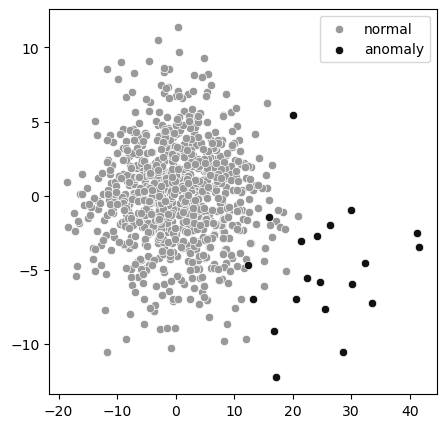

In [19]:
# コード2.22 主成分分析で次元削減したデータの散布図による描画
from sklearn.decomposition import PCA

# リストワイズ削除で欠測値削除
df_dropna = df.dropna()
# 正常データと異常データに分離し、"label"列を削除
df_normal_dropna = df_dropna[df_dropna["label"] == "normal"] \
    .drop("label", axis=1)
df_anomaly_dropna = df_dropna[df_dropna["label"] == "anomaly"] \
    .drop("label", axis=1)
# データをnumpy.ndarrayに変換
X_normal = df_normal_dropna.to_numpy()
X_anomaly = df_anomaly_dropna.to_numpy()
# 正常データから第2主成分までを学習
pca = PCA(n_components=2)
pca.fit(X_normal)
# 正常データと異常データをそれぞれ主成分分析で2次元に次元削減
X_normal_2d = pca.transform(X_normal)
X_anomaly_2d = pca.transform(X_anomaly)

# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
# 次元削減した正常データを散布図で描画
sns.scatterplot(x=X_normal_2d[:,0], y=X_normal_2d[:,1],
                color="#999999", ax=ax, label="normal")
# 次元削減した異常データを散布図で描画
sns.scatterplot(x=X_anomaly_2d[:,0], y=X_anomaly_2d[:,1],
                color="#111111", ax=ax, label="anomaly")
ax.legend()
plt.show()

この例では、主成分分析による次元削減後も、正常データと異常データの分離性がある程度保たれていることがわかります。